In [1]:
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

In [8]:
models_to_plot = ["GRU-256", "LSTM-256", "RNN-256", "TRF-256"] 
target_list_length = '5' 
dd_levels = sorted(['2', '4', '6', '8', '10'], key=int)

In [9]:
human_vsrec_data = {
    '2': [13.65/20, 14.1/20, 13.5/20, 13.65/20, 13.7/20],
    '4': [14.85/20, 14.8/20, 15.4/20, 15.1/20, 14/20],
    '6': [15.55/20, 16/20, 15.8/20, 15.6/20, 15/20]
}

In [10]:
def get_val(key, tag):
    try: return key.split(tag)[1].split("_")[0]
    except: return None

C:\Users\William\AppData\Local\Temp\ipykernel_33112\1278232273.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap('viridis_r')(np.linspace(0.1, 0.9, len(dd_levels)))


Generated VSRec Benchmark Analysis for: GRU-256


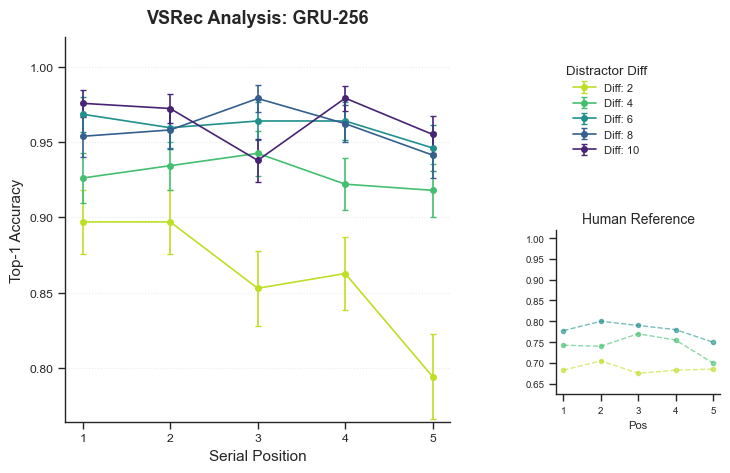

Generated VSRec Benchmark Analysis for: LSTM-256


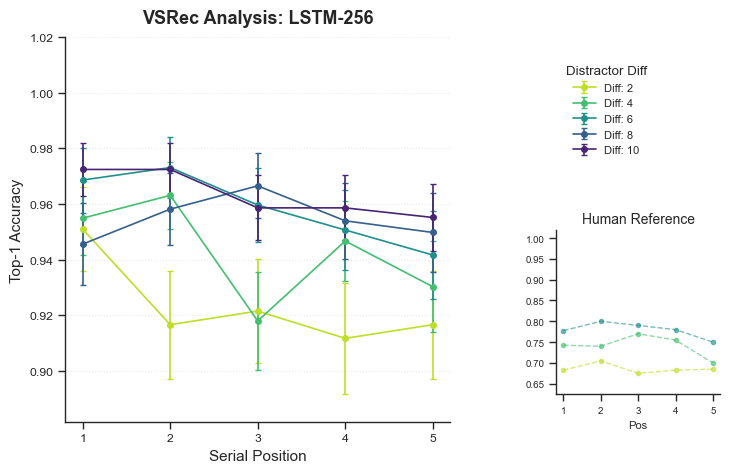

Generated VSRec Benchmark Analysis for: RNN-256


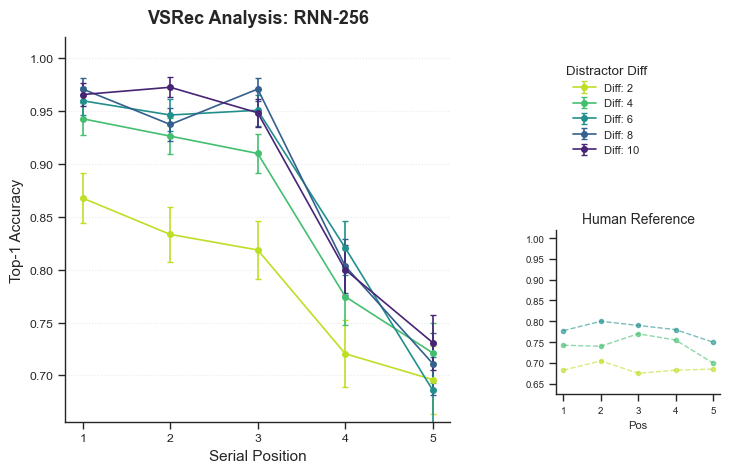

Generated VSRec Benchmark Analysis for: TRF-256


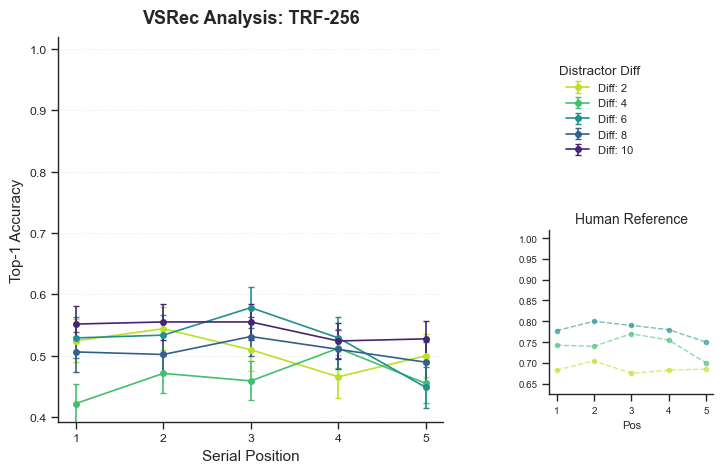

In [11]:
all_model_data = {}
human_accuracies = [val for sublist in human_vsrec_data.values() for val in sublist]


for model in models_to_plot:
    try:
        paths = [f"WM_Bench/{model}/output/test_acc_results.json", "test_acc_results.json"]
        results = None
        for p in paths:
            try:
                with open(p, "r") as f:
                    results = json.load(f)
                    break
            except FileNotFoundError: continue
        
        if results is None: continue

        m_vsrec = {} 
        for key, val in results.items():

            # Support both naming conventions
            if "VSRec_Task" in key  and f"list_length_{target_list_length}" in key:
                dd = get_val(key, "distractor_diff_") if "distractor_diff_" in key else None
                sp = get_val(key, "serial_position_") if "serial_position_" in key else None
                
                if dd in dd_levels and sp is not None:
                    acc = val[0] / val[1]
                    if dd not in m_vsrec: m_vsrec[dd] = [[], [], []]
                    m_vsrec[dd][0].append(int(sp))
                    m_vsrec[dd][1].append(acc)
                    m_vsrec[dd][2].append(np.sqrt((acc * (1 - acc)) / val[1]))
        all_model_data[model] = m_vsrec
    except Exception as e: print(f"Error processing {model}: {e}")

# Scaling for Human Reference (stays consistent across all figures)
y_min_human = min(human_accuracies) - 0.05
colors = cm.get_cmap('viridis_r')(np.linspace(0.1, 0.9, len(dd_levels)))

# Generate standalone analysis for each model
for model in all_model_data.keys():
    plt.rcParams["font.family"] = "Serif"
    sns.set_context("paper", font_scale=1.0)
    sns.set_style("ticks")

    # Layout: Model (Left) | Legend (Top Right) & Human (Bottom Right)
    fig = plt.figure(figsize=(9, 5))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.35], height_ratios=[0.4, 0.6], wspace=0.2, hspace=0.1)

    # Primary Model Plot
    ax_m = fig.add_subplot(gs[:, 0])
    ax_m.set_box_aspect(1)
    
    m_data = all_model_data[model]
    m_all_accs = [] # Collect accuracies for THIS model only
    
    for j, dd in enumerate(dd_levels):
        if dd in m_data:
            d = m_data[dd]
            idx = np.argsort(d[0])
            ax_m.errorbar(np.array(d[0])[idx], np.array(d[1])[idx], yerr=np.array(d[2])[idx], 
                          label=f'Diff: {dd}', color=colors[j], 
                          fmt='-o', markersize=4, linewidth=1.2, capsize=2)
            m_all_accs.extend(d[1])

    y_min_this_model = min(m_all_accs) - 0.03 if m_all_accs else 0.4
    ax_m.set_ylim([y_min_this_model, 1.02])
    
    ax_m.set_title(f"VSRec Analysis: {model}", fontsize=13, fontweight='bold', pad=10)
    ax_m.set_xlabel("Serial Position", fontsize=11)
    ax_m.set_ylabel("Top-1 Accuracy", fontsize=11)
    ax_m.set_xticks(range(1, 6))
    ax_m.grid(axis='y', linestyle=':', alpha=0.4)
    sns.despine(ax=ax_m)

    # Legend Panel
    ax_leg = fig.add_subplot(gs[0, 1])
    ax_leg.axis('off')
    handles, labels = ax_m.get_legend_handles_labels()
    ax_leg.legend(handles, labels, title="Distractor Diff", loc='center left', frameon=False, fontsize=8)

    # Human Subgraph (Matched Colors & Zoomed to Human Range)
    ax_h = fig.add_subplot(gs[1, 1])
    ax_h.set_box_aspect(1)
    for j, dd in enumerate(dd_levels):
        if dd in human_vsrec_data:
            h_accs = human_vsrec_data[dd]
            ax_h.plot(np.arange(1, 6), h_accs, '--o', color=colors[j], alpha=0.6, markersize=3, linewidth=1)
    
    ax_h.set_title("Human Reference", fontsize=10, pad=5)
    ax_h.set_xlabel("Pos", fontsize=8)
    ax_h.set_xticks(range(1, 6))
    ax_h.set_ylim([y_min_human, 1.02]) # Zoomed to human performance area
    ax_h.tick_params(labelsize=7)
    sns.despine(ax=ax_h)

    # Save and Display
    save_name = f"vsrec_bechmark_{model.lower()}.png"
    # plt.savefig(save_name, bbox_inches='tight', dpi=300)
    print(f"Generated VSRec Benchmark Analysis for: {model}")
    plt.show()